## Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier




## EDA

In [2]:
df = pd.read_excel('online_course_recommendation.xlsx')

In [3]:
df.shape

(100000, 14)

In [4]:
df.index

RangeIndex(start=0, stop=100000, step=1)

### Columns and Data Types

In [5]:
df.columns

Index(['user_id', 'course_id', 'course_name', 'instructor',
       'course_duration_hours', 'certification_offered', 'difficulty_level',
       'rating', 'enrollment_numbers', 'course_price', 'feedback_score',
       'study_material_available', 'time_spent_hours',
       'previous_courses_taken'],
      dtype='str')

In [6]:
numerical_columns=df.select_dtypes(include='number').columns
numerical_columns

Index(['user_id', 'course_id', 'course_duration_hours', 'rating',
       'enrollment_numbers', 'course_price', 'feedback_score',
       'time_spent_hours', 'previous_courses_taken'],
      dtype='str')

In [7]:
df.select_dtypes(include='number').columns.value_counts().sum()


np.int64(9)

In [8]:
categorical_columns=df.select_dtypes(include=['object', 'category']).columns
categorical_columns


C:\Users\Rekesh Bharathi\AppData\Local\Temp\ipykernel_11368\4028449873.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=df.select_dtypes(include=['object', 'category']).columns


Index(['course_name', 'instructor', 'certification_offered',
       'difficulty_level', 'study_material_available'],
      dtype='str')

In [9]:
df.select_dtypes(include=['object', 'category']).columns.value_counts().sum()


C:\Users\Rekesh Bharathi\AppData\Local\Temp\ipykernel_11368\453766238.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object', 'category']).columns.value_counts().sum()


np.int64(5)

In [10]:
df.dtypes

user_id                       int64
course_id                     int64
course_name                     str
instructor                      str
course_duration_hours       float64
certification_offered           str
difficulty_level                str
rating                      float64
enrollment_numbers            int64
course_price                float64
feedback_score              float64
study_material_available        str
time_spent_hours            float64
previous_courses_taken        int64
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  str    
 3   instructor                100000 non-null  str    
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  str    
 6   difficulty_level          100000 non-null  str    
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  str    
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  int64  
dtype

Based on the rough analysis on the data we see <mark> no null value </mark> 




### descriptive statistics

Descriptive Statistics for Numerical columns


In [12]:
df.describe()

,user_id,course_id,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,24935.663570,5006.863560,52.38354,3.959859,25052.822850,261.073369,0.746865,20.691054,4.992670
std,14406.960108,2882.085456,27.42347,0.729958,14388.188356,139.013758,0.143683,13.669148,2.237259
min,1.000000,1.000000,5.00000,1.000000,50.000000,20.000000,0.092000,1.000000,0.000000
25%,12487.750000,2523.000000,28.60000,3.500000,12583.750000,140.100000,0.649000,9.900000,3.000000
50%,24793.500000,5012.000000,52.40000,4.000000,25057.500000,262.310000,0.750000,19.920000,5.000000
75%,37382.250000,7502.000000,76.10000,4.500000,37522.000000,381.702500,0.851000,30.080000,6.000000
max,49999.000000,9999.000000,100.00000,5.000000,49999.000000,500.000000,1.000000,84.150000,19.000000


In [13]:
df.isnull().sum()

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64

In [14]:
df.isna().sum()

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64

In [15]:
df.shape

(100000, 14)

In [16]:
for col in df.columns:
    print('==' * 50)

    print(f"--- Column: {col} ---")
    
    print(df[col].value_counts())  # Shows the first 10 unique values


--- Column: user_id ---
user_id
37381    11
646      10
37998    10
11094     9
9128      9
         ..
10537     1
7326      1
14669     1
49654     1
12929     1
Name: count, Length: 43242, dtype: int64
--- Column: course_id ---
course_id
3658    23
4335    23
1139    23
346     22
7761    21
        ..
7525     2
8403     2
964      2
5636     2
9060     1
Name: count, Length: 9998, dtype: int64
--- Column: course_name ---
course_name
Networking and System Administration         5107
Cybersecurity for Professionals              5078
Advanced Machine Learning                    5063
Ethical Hacking Masterclass                  5062
Graphic Design with Canva                    5057
DevOps and Continuous Deployment             5037
Public Speaking Mastery                      5028
Mobile App Development with Swift            5024
Stock Market and Trading Strategies          5022
Data Visualization with Tableau              5010
AI for Business Leaders                      5007
Photogra

### Identifying and Handeling Duplicates

In [17]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [18]:
print(df.duplicated().sum())

0


### Outliers    


In [19]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Count outliers for this specific column
    num_outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0]
    
    print(f"Column: {col:20} | Outliers: {num_outliers:5} | Limits: ({lower_limit:.2f}, {upper_limit:.2f})")

Column: user_id              | Outliers:     0 | Limits: (-24854.00, 74724.00)
Column: course_id            | Outliers:     0 | Limits: (-4945.50, 14970.50)
Column: course_duration_hours | Outliers:     0 | Limits: (-42.65, 147.35)
Column: rating               | Outliers:   529 | Limits: (2.00, 6.00)
Column: enrollment_numbers   | Outliers:     0 | Limits: (-24823.62, 74929.38)
Column: course_price         | Outliers:     0 | Limits: (-222.30, 744.11)
Column: feedback_score       | Outliers:   377 | Limits: (0.35, 1.15)
Column: time_spent_hours     | Outliers:   342 | Limits: (-20.37, 60.35)
Column: previous_courses_taken | Outliers:  1373 | Limits: (-1.50, 10.50)


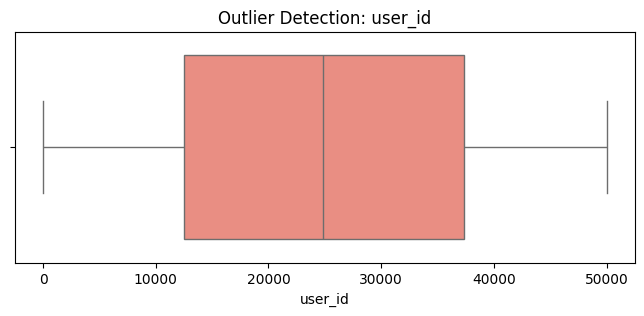

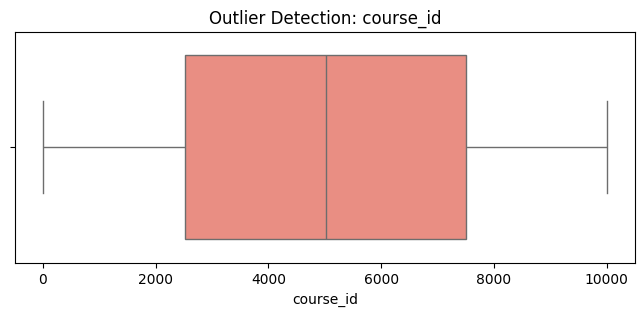

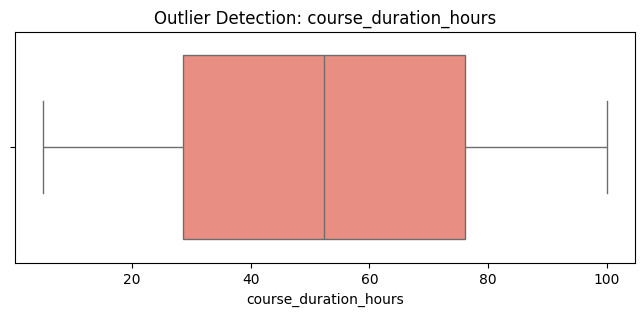

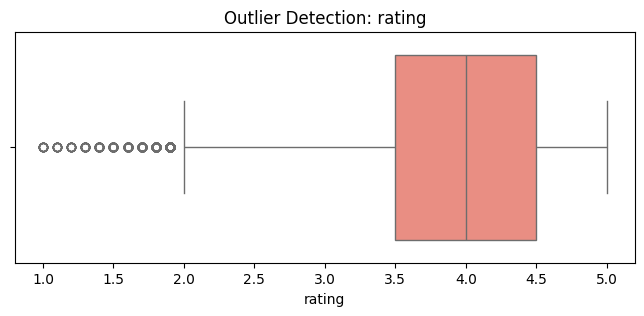

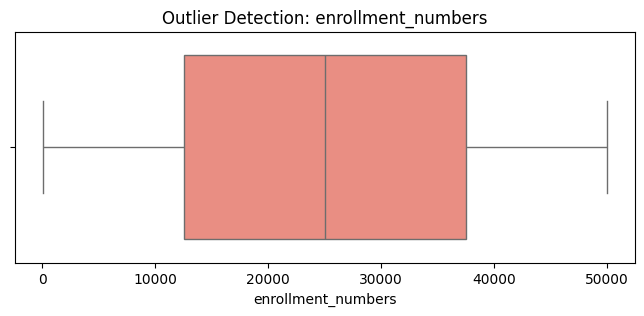

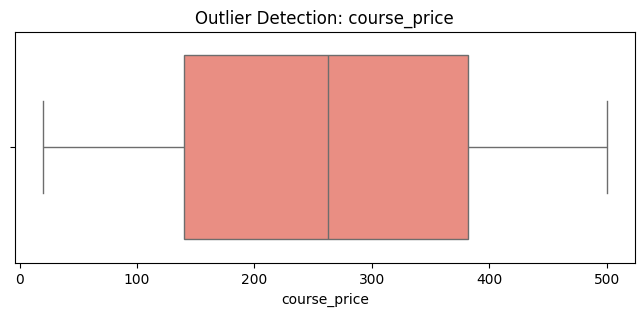

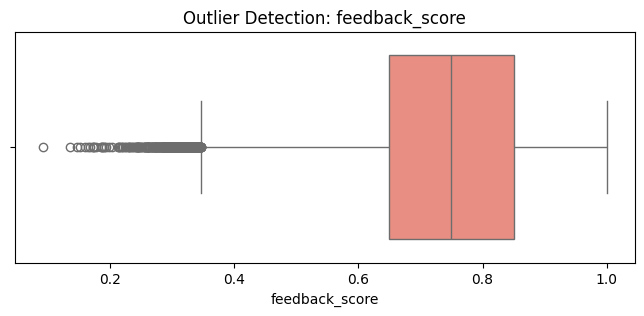

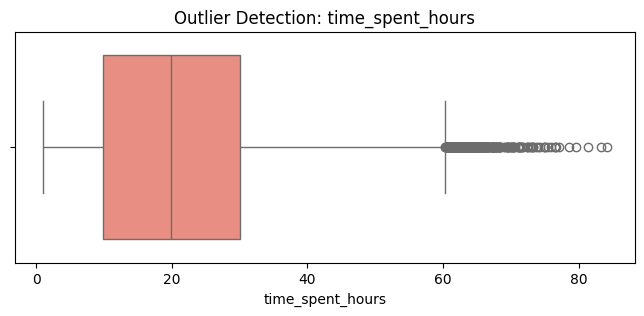

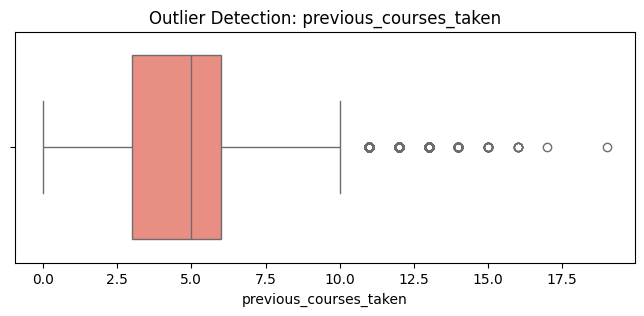

In [20]:
# Loop through each numeric column and print the plot
for col in numerical_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Outlier Detection: {col}')
    plt.show()


### Visualizatoins

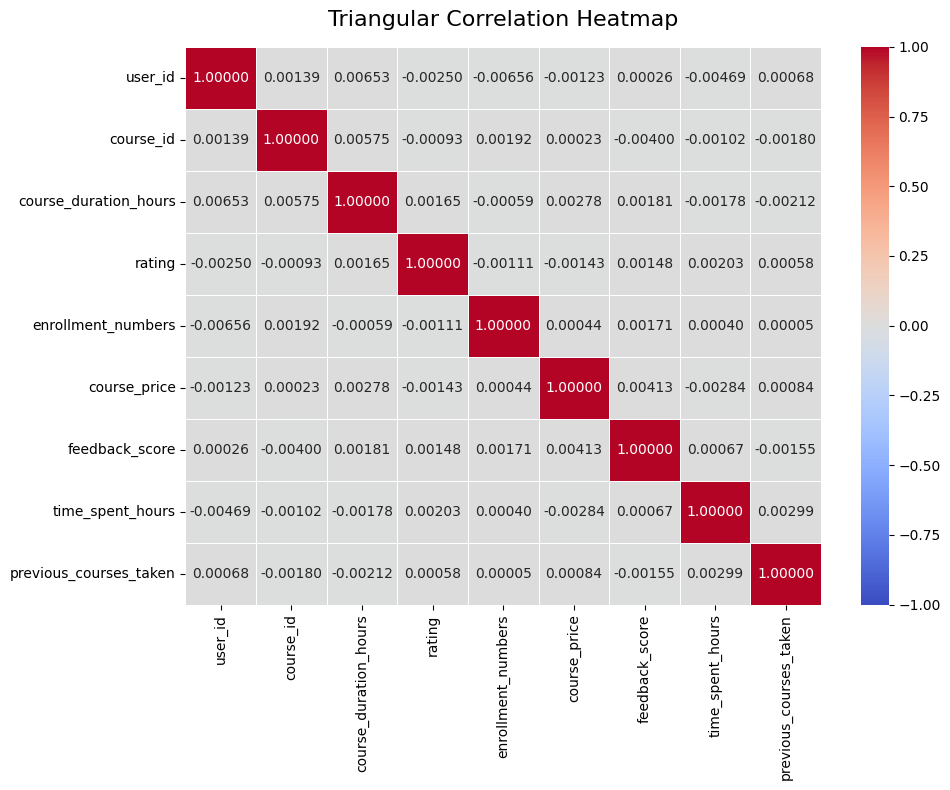

In [21]:
corr_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".5f", 
    linewidths=0.5, 
    vmin=-1, vmax=1
)

plt.title('Triangular Correlation Heatmap', fontsize=16, pad=15)
plt.tight_layout()
plt.show()


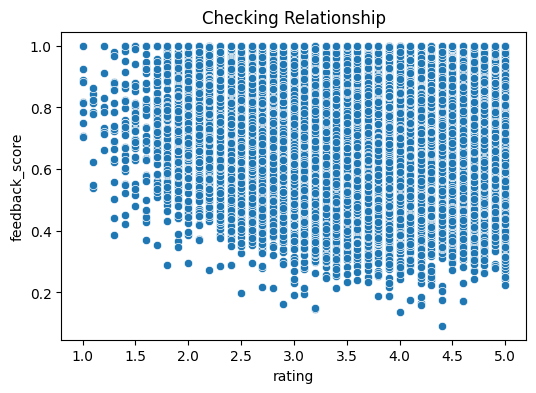

In [22]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='rating', y='feedback_score')
plt.title('Checking Relationship')
plt.show()


In [23]:
cols = 3
all_cols = df.columns.tolist()
n = len(all_cols)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, all_cols):
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(
            df[col].dropna(),
            kde=True,
            stat="density",
            bins=20,
            color="skyblue",
            edgecolor="black",
            ax=ax,
        )
        ax.set_ylabel("Density")
        ax.set_title(f"{col} — Numeric")
    else:
        counts = df[col].value_counts()
        sns.barplot(
            x=counts.index.astype(str),
            y=counts.values,
            palette="pastel",
            ax=ax,
        )
        x = np.arange(len(counts))
        if len(x) > 1:
            x_smooth = np.linspace(x.min(), x.max(), 200)
            y_smooth = np.interp(x_smooth, x, counts.values)
            ax2 = ax.twinx()
            ax2.plot(x_smooth, y_smooth, color="red", alpha=0.85)
            ax2.set_ylabel("Smoothed count", color="red")
            ax2.tick_params(axis="y", labelcolor="red")
        ax.set_xticklabels(counts.index.astype(str), rotation=45, ha="right")
        ax.set_ylabel("Count")
        ax.set_title(f"{col} — Categorical")

    ax.set_xlabel(col)

for extra_ax in axes[n:]:
    fig.delaxes(extra_ax)

plt.tight_layout()
plt.show()

NameError: name 'math' is not defined

## Creating new features

In [ ]:
def calculate_engagement_index(df):

    time_taken = df['time_spent_hours']
    duration = df['course_duration_hours']
    sweet_spot_limit = 1.3 * duration

    # Define our 3 conditions
    conditions = [
        (time_taken < duration),                                      # 1. Under-Time
        (time_taken >= duration) & (time_taken <= sweet_spot_limit), # 2. Sweet-Spot
        (time_taken > sweet_spot_limit)                              # 3. Over-Time
    ]

    # Define the mathematical formulas for each condition
    under_time_formula = time_taken / duration
    sweet_spot_formula = 1.0
    over_time_formula = 1.0 - ((time_taken - sweet_spot_limit) / duration)

    # Apply the over-time formula but enforce the 0.1 lower bound floor using np.maximum
    over_time_penalized = np.maximum(over_time_formula, 0.1)

    # Choices array matching our conditions
    choices = [under_time_formula, sweet_spot_formula, over_time_penalized]

    # Execute vectorization
    df['Engagement_Index'] = np.select(conditions, choices, default=0.0)
    
    return df

# Apply the function to your dataframe
df = calculate_engagement_index(df)

# Let's check a quick statistical summary of your new engineered feature!
print(df['Engagement_Index'].describe())
print("=="*50)
print()
# Sample one user from each behavior bracket to verify the logic
print(df[['course_duration_hours', 'time_spent_hours', 'Engagement_Index']].head(10))

count    100000.000000
mean          0.384168
std           0.291597
min           0.010000
25%           0.130088
50%           0.324842
75%           0.573412
max           1.000000
Name: Engagement_Index, dtype: float64

   course_duration_hours  time_spent_hours  Engagement_Index
0                   39.1             17.60          0.450128
1                   36.3             28.97          0.798072
2                   13.4             52.44          0.100000
3                   58.3             22.29          0.382333
4                   30.8             22.01          0.714610
5                   76.7              5.73          0.074707
6                   44.9             15.66          0.348775
7                   98.3             17.25          0.175483
8                   68.5             26.24          0.383066
9                   45.7             23.45          0.513129


Category 1: Linear Ramping (Under-Time Learners)When it's used: When a user's spent time is strictly less than the course duration <mark> (time_spent_hours < course_duration_hours).The Calculation: Simple Ratio Division$$\text{Score} = \frac{\text{Time Spent}}{\text{Course Duration}}$$ </mark>How the math works: This calculation scales linearly from near 0.0 up to 1.0. If a course is 50 hours long and they only stay for 25 hours, the division yields a score of 0.50. The lower their time compared to the duration, the lower their score.

Category 2: Constant Assignment (Sweet-Spot Learners)When it's used: When a user's spent time matches the course duration or goes up to 30% over <mark>(course_duration_hours <= time_spent_hours <= 1.3 * course_duration_hours)</mark>.The Calculation: Direct Scalar Mapping

$$\text{Score} = 1.0$$

How the math works: There is no division or subtraction here. The model bypasses calculations and directly assigns a flat, perfect score of 1.0. This treats any time spent within this entire baseline range as equally ideal.

Category 3: Linear Penalty with a Hard Floor (Over-Time Learners)When it's used: When a user's spent time exceeds the 30% safety buffer <mark>(time_spent_hours > 1.3 * course_duration_hours)</mark>.The Calculation: Subtractive Distance Penalty combined with a Maximum Boundary Function$$\text{Score} = \max\left(1.0 - \frac{\text{Time Spent} - \text{Buffer Threshold}}{\text{Course Duration}},\, 0.1\right)$$

In [ ]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken,Engagement_Index
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4,0.450128
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9,0.798072
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4,0.100000
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6,0.382333
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5,0.714610


In [ ]:

# Normalize rating to a 0.1 - 1.0 scale to match the others
df['Normalized_Rating'] = df['rating'] / 5.0

# Calculate a weighted satisfaction index
# Giving 40% weight to explicit rating, 40% to engagement, and 20% to text feedback proxy
df['Value_Score'] = (df['Normalized_Rating'] * 0.4) + (df['Engagement_Index'] * 0.4) + (df['feedback_score'] * 0.2)

df['Value_Score']

0        0.739451
1        0.817229
2        0.506400
3        0.594733
4        0.620844
           ...   
99995    0.857635
99996    0.709663
99997    0.628016
99998    0.683888
99999    0.386122
Name: Value_Score, Length: 100000, dtype: float64

In [ ]:
df['Value_Score'].describe()


count    100000.000000
mean          0.619829
std           0.133634
min           0.199530
25%           0.521795
50%           0.602922
75%           0.708688
max           1.000000
Name: Value_Score, dtype: float64

In [ ]:
# Use np.inf as the final boundary to automatically capture all high-value outliers
df['User_Experience_Tier'] = pd.cut(df['previous_courses_taken'], 
                                    bins=[-1, 2, 6, np.inf], 
                                    labels=[0, 1, 2])

# Now it can safely convert to integer because there are zero unmapped NaN values!
df['User_Experience_Tier'] = df['User_Experience_Tier'].astype(int)

# Let's verify that the value distribution matches our expectations
print(df['User_Experience_Tier'].value_counts())
print("=="*30)
print(df[['previous_courses_taken', 'User_Experience_Tier']].head(10))

User_Experience_Tier
1    63735
2    23638
0    12627
Name: count, dtype: int64
   previous_courses_taken  User_Experience_Tier
0                       4                     1
1                       9                     2
2                       4                     1
3                       6                     1
4                       5                     1
5                       6                     1
6                       3                     1
7                       7                     2
8                       4                     1
9                       7                     2


In [ ]:
# Calculate the true average engagement for each unique course
course_quality_map = df.groupby('course_id')['Engagement_Index'].mean().to_dict()

# Map it back as a permanent feature of the course
df['Course_Expected_Engagement'] = df['course_id'].map(course_quality_map)

df['Course_Expected_Engagement']

0        0.447549
1        0.357311
2        0.292402
3        0.385176
4        0.256049
           ...   
99995    0.478977
99996    0.580956
99997    0.384931
99998    0.523832
99999    0.500974
Name: Course_Expected_Engagement, Length: 100000, dtype: float64

In [ ]:
df['Course_Expected_Engagement'].describe()

count    100000.000000
mean          0.384168
std           0.091653
min           0.035596
25%           0.320723
50%           0.380998
75%           0.443533
max           0.797010
Name: Course_Expected_Engagement, dtype: float64

In [ ]:
df.columns

Index(['user_id', 'course_id', 'course_name', 'instructor',
       'course_duration_hours', 'certification_offered', 'difficulty_level',
       'rating', 'enrollment_numbers', 'course_price', 'feedback_score',
       'study_material_available', 'time_spent_hours',
       'previous_courses_taken', 'Engagement_Index', 'Normalized_Rating',
       'Value_Score', 'User_Experience_Tier', 'Course_Expected_Engagement'],
      dtype='str')

## Scalling and encoding

### Label Encoding for Categorical Features

In [ ]:

# Going to encode the binary Yes/No columns and difficulty levels
le = LabelEncoder()

df['certification_offered_enc'] = le.fit_transform(df['certification_offered'])
df['difficulty_level_enc']       = le.fit_transform(df['difficulty_level'])
df['study_material_available_enc'] = le.fit_transform(df['study_material_available'])

print('Encoding done!')
print(df[['certification_offered', 'certification_offered_enc']].drop_duplicates())
print()
print(df[['difficulty_level', 'difficulty_level_enc']].drop_duplicates().sort_values('difficulty_level_enc'))
print()
print(df[['study_material_available', 'study_material_available_enc']].drop_duplicates())

Encoding done!
  certification_offered  certification_offered_enc
0                   Yes                          1
7                    No                          0

  difficulty_level  difficulty_level_enc
5         Advanced                     0
0         Beginner                     1
9     Intermediate                     2

  study_material_available  study_material_available_enc
0                      Yes                             1
3                       No                             0


## Creating the Target Variable


In [ ]:
# Normalizing the Rating

# Map the explicit 1-5 rating into a 0.0 to 1.0 scale
df['Normalized_Rating'] = (df['rating'] - 1) / (5 - 1)

In [ ]:
df.columns.to_list()

['user_id',
 'course_id',
 'course_name',
 'instructor',
 'course_duration_hours',
 'certification_offered',
 'difficulty_level',
 'rating',
 'enrollment_numbers',
 'course_price',
 'feedback_score',
 'study_material_available',
 'time_spent_hours',
 'previous_courses_taken',
 'Engagement_Index',
 'Normalized_Rating',
 'Value_Score',
 'User_Experience_Tier',
 'Course_Expected_Engagement',
 'certification_offered_enc',
 'difficulty_level_enc',
 'study_material_available_enc']

In [ ]:
# Defining balance weights
w_rating = 0.40
w_engagement = 0.40
w_feedback = 0.20

# Compute the composite structural utility score
df['Utility_Score'] = (
    (df['Normalized_Rating'] * w_rating) + 
    (df['Engagement_Index'] * w_engagement) + 
    (df['feedback_score'] * w_feedback)
)


In [ ]:
# Find the exact median point of your composite utility score
utility_median = df['Utility_Score'].median()

# Binarize into your clean target feature
df['Recommended'] = (df['Utility_Score'] >= utility_median).astype(int)

# Verify the clean, balanced target distribution!
print('Balanced Target Distribution:')
print(df['Recommended'].value_counts())
print()
print(f"Positive class ratio: {df['Recommended'].mean():.2%}")

Balanced Target Distribution:
Recommended
1    50000
0    50000
Name: count, dtype: int64

Positive class ratio: 50.00%


In [ ]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,...,Engagement_Index,Normalized_Rating,Value_Score,User_Experience_Tier,Course_Expected_Engagement,certification_offered_enc,difficulty_level_enc,study_material_available_enc,Utility_Score,Recommended
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,...,0.450128,1.000,0.739451,1,0.447549,1,1,1,0.739451,1
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,...,0.798072,0.825,0.817229,2,0.357311,1,1,1,0.803229,1
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,...,0.100000,0.725,0.506400,1,0.292402,1,1,1,0.484400,0
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,...,0.382333,0.525,0.594733,1,0.385176,1,1,0,0.556733,0
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,...,0.714610,0.450,0.620844,1,0.256049,1,1,1,0.576844,0


### Selecting Features & Scaling

In [ ]:
# Drop columns that directly contain the answer or were used to calculate the target formula
X = df.drop(columns=[
    'Recommended',                # The target label
    'Utility_Score',               # The continuous score we generated
    'Normalized_Rating',           # Used in the formula
    'rating',                      # Parent column used in formula
    'Engagement_Index',            # Used in the formula
    'feedback_score',              # Used in the formula
    'Value_Score',                 # Drop old/redundant composite metrics
    'time_spent_hours',            # Parent column used to make engagement index
    'course_duration_hours',       # Parent column used to make engagement index
    
    # Drop unencoded text objects and raw tracking IDs
    'user_id', 'course_id', 'course_name', 'instructor',
    'certification_offered', 'difficulty_level', 'study_material_available'
])

# Your target array
y = df['Recommended']

print("Features selected for training:")
print()
print(X.columns.tolist())
print()
print(f"Number of features: {X.columns.size}")

Features selected for training:

['enrollment_numbers', 'course_price', 'previous_courses_taken', 'User_Experience_Tier', 'Course_Expected_Engagement', 'certification_offered_enc', 'difficulty_level_enc', 'study_material_available_enc']

Number of features: 8


In [ ]:
# Splitting before scaling to prevent any data leakage from test into train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Test  size : {X_test.shape[0]:,}')

Train size : 80,000
Test  size : 20,000


In [ ]:
# Fit on train only — transform both
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling complete.')
print('Mean of first feature (train, post-scale):', X_train_sc[:, 0].mean().round(6))

Scaling complete.
Mean of first feature (train, post-scale): 0.0


## Model Building

### Logistic Regression (Baseline)

In [ ]:
# Logistic Regression as a simple baseline to compare against
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

lr_preds = lr_model.predict(X_test_sc)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_auc   = roc_auc_score(y_test, lr_model.predict_proba(X_test_sc)[:, 1])

print(f'Logistic Regression Accuracy : {lr_acc:.4f}')
print(f'Logistic Regression AUC      : {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['Not Recommended', 'Recommended']))

Logistic Regression Accuracy : 0.5803
Logistic Regression AUC      : 0.6174

                 precision    recall  f1-score   support

Not Recommended       0.58      0.59      0.59     10000
    Recommended       0.58      0.57      0.57     10000

       accuracy                           0.58     20000
      macro avg       0.58      0.58      0.58     20000
   weighted avg       0.58      0.58      0.58     20000



### Decision Tree Classifier

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=20, random_state=42)
dt_model.fit(X_train_sc, y_train)

dt_preds = dt_model.predict(X_test_sc)
dt_acc   = accuracy_score(y_test, dt_preds)
dt_auc   = roc_auc_score(y_test, dt_model.predict_proba(X_test_sc)[:, 1])

print(f'Decision Tree Accuracy : {dt_acc:.4f}')
print(f'Decision Tree AUC      : {dt_auc:.4f}')
print()
print(classification_report(y_test, dt_preds, target_names=['Not Recommended', 'Recommended']))

Decision Tree Accuracy : 0.5746
Decision Tree AUC      : 0.6039

                 precision    recall  f1-score   support

Not Recommended       0.58      0.55      0.56     10000
    Recommended       0.57      0.60      0.59     10000

       accuracy                           0.57     20000
      macro avg       0.57      0.57      0.57     20000
   weighted avg       0.57      0.57      0.57     20000



### Random Forest Classifier

In [ ]:
# Random Forest — ensemble of trees, usually performs very well on tabular data
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sc, y_train)

rf_preds = rf_model.predict(X_test_sc)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_auc   = roc_auc_score(y_test, rf_model.predict_proba(X_test_sc)[:, 1])

print(f'Random Forest Accuracy : {rf_acc:.4f}')
print(f'Random Forest AUC      : {rf_auc:.4f}')
print()
print(classification_report(y_test, rf_preds, target_names=['Not Recommended', 'Recommended']))

Random Forest Accuracy : 0.5599
Random Forest AUC      : 0.5864

                 precision    recall  f1-score   support

Not Recommended       0.56      0.56      0.56     10000
    Recommended       0.56      0.56      0.56     10000

       accuracy                           0.56     20000
      macro avg       0.56      0.56      0.56     20000
   weighted avg       0.56      0.56      0.56     20000



### Gradient Boosting Classifier

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train_sc, y_train)

gb_preds = gb_model.predict(X_test_sc)
gb_acc   = accuracy_score(y_test, gb_preds)
gb_auc   = roc_auc_score(y_test, gb_model.predict_proba(X_test_sc)[:, 1])

print(f'Gradient Boosting Accuracy : {gb_acc:.4f}')
print(f'Gradient Boosting AUC      : {gb_auc:.4f}')
print()
print(classification_report(y_test, gb_preds, target_names=['Not Recommended', 'Recommended']))

Gradient Boosting Accuracy : 0.5787
Gradient Boosting AUC      : 0.6103

                 precision    recall  f1-score   support

Not Recommended       0.58      0.57      0.58     10000
    Recommended       0.58      0.59      0.58     10000

       accuracy                           0.58     20000
      macro avg       0.58      0.58      0.58     20000
   weighted avg       0.58      0.58      0.58     20000



In [ ]:
# Initialize LightGBM with robust regularization to optimize scores
lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    random_state=42
)

lgb_model.fit(X_train_sc, y_train)
lgb_preds = lgb_model.predict(X_test_sc)
lgb_acc = accuracy_score(y_test, lgb_preds)

print(f"LightGBM Test Accuracy : {lgb_acc:.4f}")


[LightGBM] [Info] Number of positive: 40000, number of negative: 40000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Test Accuracy : 0.5752


d:\excelar\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import GridSearchCV


# 1. Define the collection of candidate algorithms
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

# 2. Define custom hyperparameter grids tailored strictly to each specific model
param_grids = {
    'LogisticRegression': {
        'C': [0.1, 1.0, 10.0]  # Regularization strength
    },
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 8],
        'min_samples_split': [2, 5]
    },
    'GradientBoosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.1, 0.2],
        'max_depth': [3, 4]
    }
}

# Dictionary to keep track of the champion versions of each model family
best_models = {}

# 3. Loop through each model family, run its own Grid Search, and find its best score
for model_name in models.keys():
    print(f"=== Starting Grid Search Optimization for: {model_name} ===")
    
    grid_search = GridSearchCV(
        estimator=models[model_name],
        param_grid=param_grids[model_name],
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the isolated grid on your scaled training metrics
    grid_search.fit(X_train_sc, y_train)
    
    # Store the optimized estimator object
    best_models[model_name] = grid_search.best_estimator_
    
    print(f"Best Params for {model_name}: {grid_search.best_params_}")
    print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}\n")

print("==================================================")
print("All model optimizations completed successfully! You can now validate them on the test set.")

=== Starting Grid Search Optimization for: LogisticRegression ===
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Params for LogisticRegression: {'C': 1.0}
Best Cross-Validation Score: 0.5874

=== Starting Grid Search Optimization for: RandomForest ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for RandomForest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.5874

=== Starting Grid Search Optimization for: GradientBoosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for GradientBoosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation Score: 0.5858

All model optimizations completed successfully! You can now validate them on the test set.


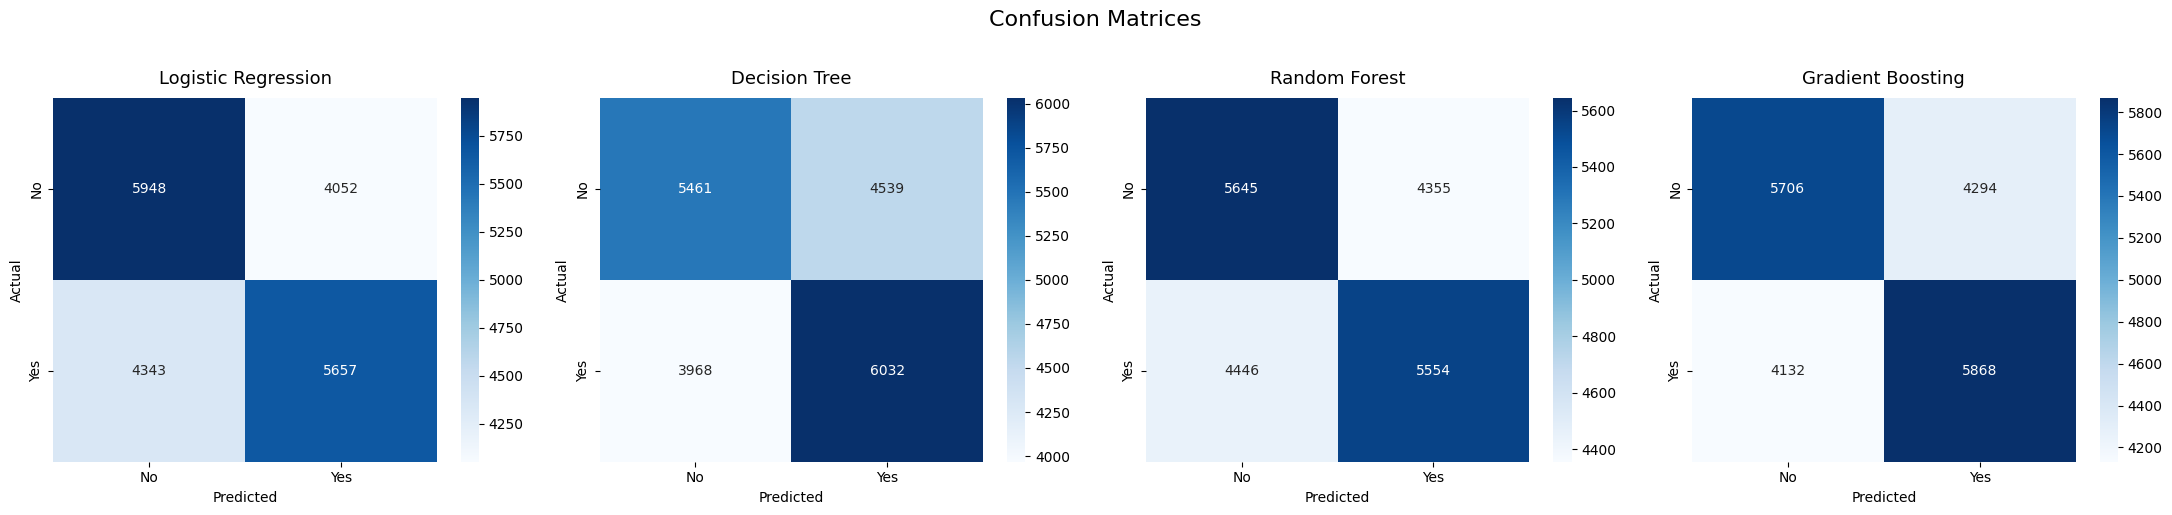

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models_info = [
    ('Logistic Regression', lr_preds),
    ('Decision Tree',       dt_preds),
    ('Random Forest',       rf_preds),
    ('Gradient Boosting',   gb_preds),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(name, fontsize=13, pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()